In [55]:
# ==============================================================================
# Cell 1: Import Required Libraries
# ==============================================================================
# pandas: for data loading, filtering, grouping, and manipulation
import pandas as pd

# numpy: used for numerical data types and operations
import numpy as np

# matplotlib.pyplot: base plotting engine for creating figures, axes, and custom charts
import matplotlib.pyplot as plt

# seaborn: higher-level statistical data visualization built on top of matplotlib
import seaborn as sns

# Set a clean default background grid style for all plots
sns.set_theme(style="whitegrid")

In [56]:
# ==============================================================================
# Cell 2: Kirby21 Data Loading & Subject Filtering
# ==============================================================================
# Define raw GitHub URL pointing directly to the Kirby21 dataset CSV
kirby21_url = "https://raw.githubusercontent.com/smart-stats/ds4bio_book/main/book/assetts/kirby21AllLevels.csv"

# Load the CSV file into a pandas DataFrame named kirb21_df
kirb21_df = pd.read_csv(kirby21_url)

# Filter rows where the 'rawid' matches the target subject 'kirby906a_ax.img'
# .copy() prevents SettingWithCopyWarning when modifying the subset later
kirby906a_ax_df = kirb21_df[kirb21_df["rawid"] == "kirby906a_ax.img"].copy()

In [57]:
# ==============================================================================
# Cell 3: Telencephalon Volumes & Volume Fractions
# ==============================================================================
# Filter subject data to Type 1, Level 1
t1_l1 = kirby906a_ax_df[(kirby906a_ax_df["type"] == 1) & (kirby906a_ax_df["level"] == 1)]

# 1. Extract left and right telencephalon volumes as pure scalar floats
telencephalon_L_volume = float(t1_l1[t1_l1["roi"] == "Telencephalon_L"]["volume"].values[0])
telencephalon_R_volume = float(t1_l1[t1_l1["roi"] == "Telencephalon_R"]["volume"].values[0])

# Combined telencephalon volume
total_telencephalon = telencephalon_L_volume + telencephalon_R_volume

# 2. Compute ICV and TBV from Level 1
# ICV represents the total cranial volume (all Type 1, Level 1 regions combined)
icv_volume = float(t1_l1["volume"].sum())

# TBV represents total brain tissue (all Type 1, Level 1 regions excluding CSF/ventricles)
# If CSF is in the list, exclude it; otherwise sum the brain parenchymal tissues
tbv_volume = float(t1_l1[~t1_l1["roi"].str.contains("CSF|ventricle", case=False, na=False)]["volume"].sum())

# 3. Calculate fractions
ICV_fraction = float(total_telencephalon / icv_volume)
TBV_fraction = float(total_telencephalon / tbv_volume)

# 4. Print results
print(telencephalon_L_volume)
print(telencephalon_R_volume)
print(ICV_fraction)
print(TBV_fraction)

467063.0
470488.0
0.7845516583473847
0.8348063710737297


In [58]:
# ==============================================================================
# Cell 4: Aggregated Volume for Every Type and Level
# ==============================================================================
# Group entire dataset by ('type', 'level') and sum the 'volume' column across all regions
# .reset_index(name="total_volume") flattens the grouped indices into standard columns
all_regions_df = (
    kirb21_df.groupby(["type", "level"])["volume"]
    .sum()
    .reset_index(name="total_volume")
)

# Display the resulting DataFrame
all_regions_df

,type,level,total_volume
0,1,1,25622342
1,1,2,25622426
2,1,3,25622693
3,1,4,25623353
4,1,5,25624463
5,2,1,25622320
6,2,2,25622426
7,2,3,25622689
8,2,4,25622825
9,2,5,25623870


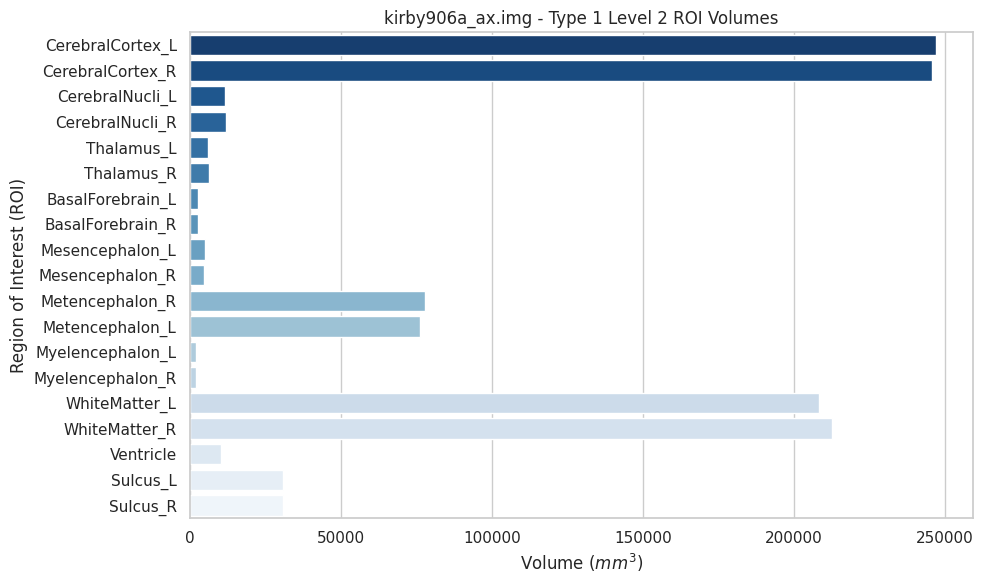

In [59]:
# ==============================================================================
# Cell 5: Bar Plot of Type 1 Level 2 Data for kirby906a_ax.img
# ==============================================================================
# Subset subject data to Type 1, Level 2 regions
t1_l2 = kirby906a_ax_df[(kirby906a_ax_df["type"] == 1) & (kirby906a_ax_df["level"] == 2)]

# Initialize figure container with dimensions (width=10, height=6 inches)
plt.figure(figsize=(10, 6))

# Generate horizontal bar plot using seaborn for clear label readability
sns.barplot(data=t1_l2, x="volume", y="roi", hue="roi", palette="Blues_r", legend=False)

# Add descriptive chart labels and title
plt.title("kirby906a_ax.img - Type 1 Level 2 ROI Volumes")
plt.xlabel("Volume ($mm^3$)")
plt.ylabel("Region of Interest (ROI)")

# Adjust padding automatically so axis labels are not clipped
plt.tight_layout()

# Render plot to notebook output
plt.show()

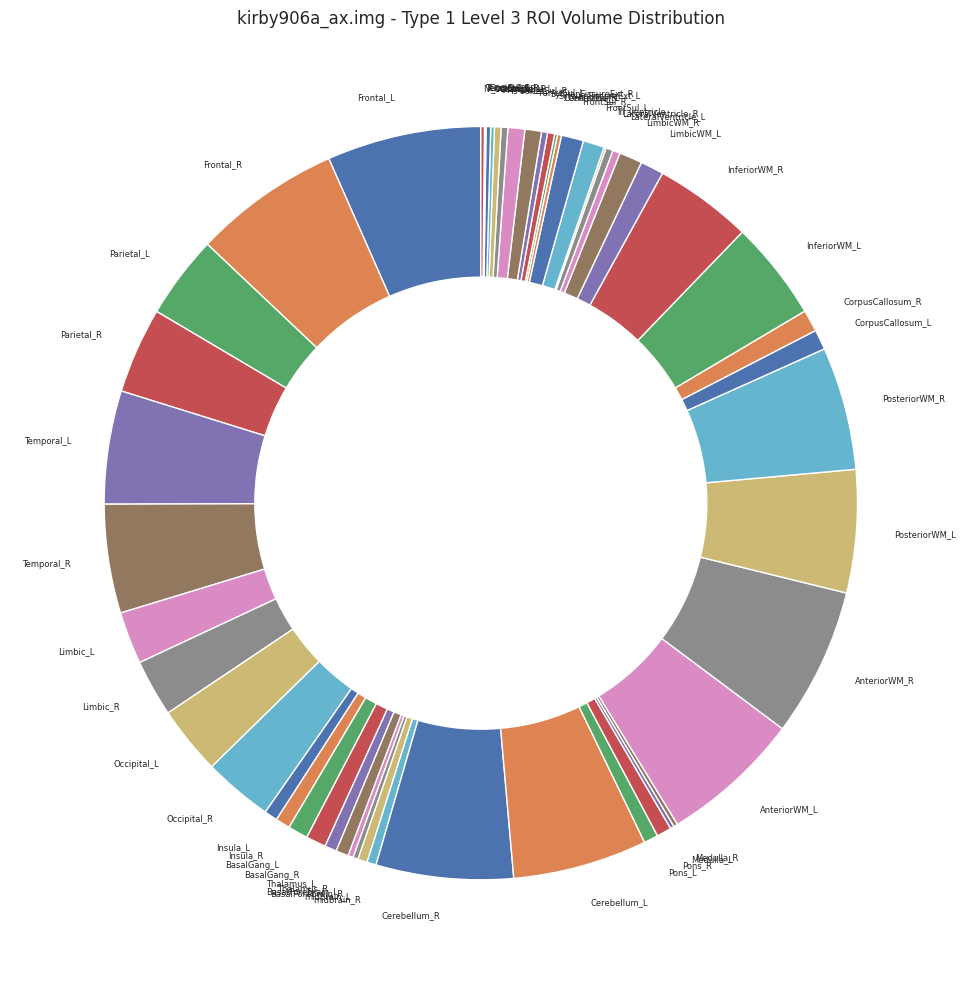

In [60]:
# ==============================================================================
# Cell 6: Donut Chart of Type 1 Level 3 Data for kirby906a_ax.img
# ==============================================================================
# Subset subject data to Type 1, Level 3 regions
t1_l3 = kirby906a_ax_df[(kirby906a_ax_df["type"] == 1) & (kirby906a_ax_df["level"] == 3)]

# Create figure and axis objects
fig, ax = plt.subplots(figsize=(10, 10))

# Build standard pie chart; width=0.4 carves out the central core to form a donut
wedges, texts = ax.pie(
    t1_l3["volume"],
    labels=t1_l3["roi"],
    startangle=90,                                  # Rotate starting slice to 12 o'clock
    wedgeprops=dict(width=0.4, edgecolor="white")  # Donut thickness and slice border lines
)

# Reduce font size of slice labels to prevent overlapping
plt.setp(texts, size=6)

# Set chart title
ax.set_title("kirby906a_ax.img - Type 1 Level 3 ROI Volume Distribution")

# Adjust layout to fit labels within figure boundaries
plt.tight_layout()

# Render plot to notebook output
plt.show()

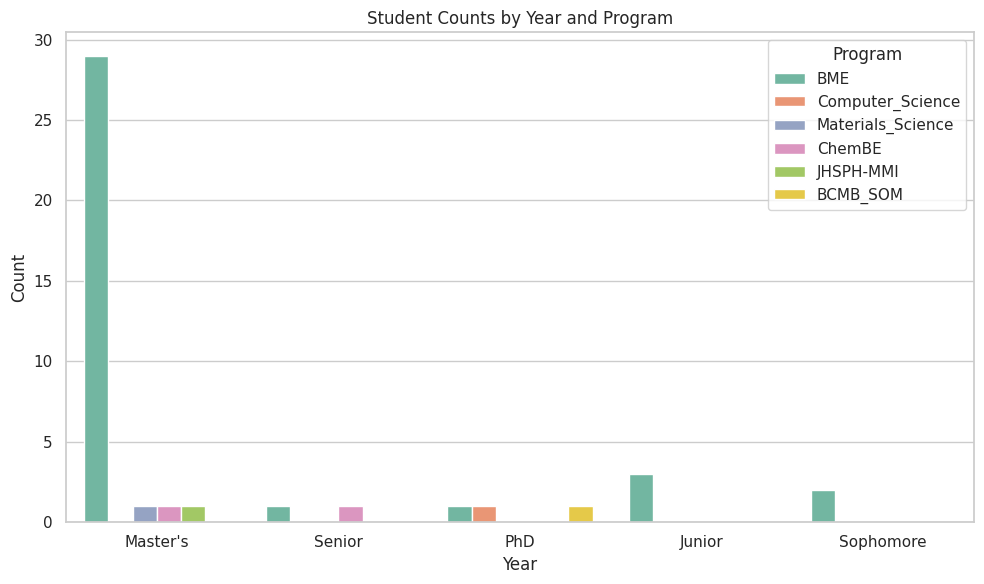

In [61]:
# ==============================================================================
# Cell 7: Class Interests Data & Grouped Bar Plot
# ==============================================================================
# Raw URL for the tab-delimited text file
class_interests_url = "https://raw.githubusercontent.com/bcaffo/ds4bme/master/data/classInterests.txt"

# Read tab-separated data into DataFrame
class_interests_df = pd.read_csv(class_interests_url, sep="\t")

# Locate column names dynamically by checking lowercase substrings ('year' and 'program')
cols = class_interests_df.columns
year_col = [c for c in cols if "year" in c.lower()][0]
prog_col = [c for c in cols if "program" in c.lower()][0]

# Initialize figure size
plt.figure(figsize=(10, 6))

# Plot category counts: x-axis = Year, split/grouped (hue) = Academic Program
sns.countplot(data=class_interests_df, x=year_col, hue=prog_col, palette="Set2")

# Configure plot annotations
plt.title("Student Counts by Year and Program")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend(title="Program")

# Optimize spacing
plt.tight_layout()

# Render plot to notebook output
plt.show()

In [62]:
# ==============================================================================
# Cell 8: Gene Expression Matrix Transformations
# ==============================================================================
# Raw URL for the GSE5859 gene expression CSV
gene_expr_url = "https://raw.githubusercontent.com/jhu-advdatasci/2018/refs/heads/master/data/GSE5859_exprs.csv"

# Load data with index_col=0 so gene IDs are assigned to index, leaving numeric columns
gene_expression_df = pd.read_csv(gene_expr_url, index_col=0)

# 1) Center rows: compute mean along each row (axis=1), subtract from each row element (axis=0)
gene_expression_df_pt1 = gene_expression_df.sub(gene_expression_df.mean(axis=1), axis=0)

# 2) Center columns: compute mean along each column (axis=0), subtract from each column element (axis=1)
gene_expression_df_pt2 = gene_expression_df_pt1.sub(gene_expression_df_pt1.mean(axis=0), axis=1)

# 3) Scale columns: compute column standard deviations (axis=0), divide each column by its standard deviation
gene_expression_df_pt3 = gene_expression_df_pt2.div(gene_expression_df_pt2.std(axis=0), axis=1)

# Preview transformed data
gene_expression_df_pt3.head()

,GSM25581.CEL.gz,GSM25681.CEL.gz,GSM136524.CEL.gz,GSM136707.CEL.gz,GSM25553.CEL.gz,GSM136676.CEL.gz,GSM136711.CEL.gz,GSM136542.CEL.gz,GSM136535.CEL.gz,GSM25399.CEL.gz,...,GSM48650.CEL.gz,GSM25687.CEL.gz,GSM25685.CEL.gz,GSM136549.CEL.gz,GSM25427.CEL.gz,GSM25525.CEL.gz,GSM25349.CEL.gz,GSM136727.CEL.gz,GSM25626.CEL.gz,GSM136725.CEL.gz
1007_s_at,-0.062810,-1.694428,-0.797346,0.362538,-1.152413,0.366177,1.252187,-0.054154,1.008166,-0.730639,...,1.446603,-0.185273,1.615970,0.245537,-0.568262,-0.069236,0.617954,-0.598607,0.088393,0.257410
1053_at,0.484259,0.835005,1.434085,-0.316432,0.141554,-0.076237,-0.745136,-0.148166,-0.250652,-0.497815,...,-1.094982,0.985940,0.538265,-0.521649,0.195814,0.365237,-0.422815,0.408542,-1.573530,1.173822
117_at,0.789673,-1.707110,-1.548943,-0.245036,-1.015618,-0.637799,-1.096388,-1.031533,0.992122,0.696068,...,1.564055,-0.694512,-0.395453,0.904341,-0.130702,0.080440,-0.977132,-0.197351,0.140632,-0.701024
121_at,-1.599798,-1.460817,-0.134750,1.138467,-1.255766,1.368016,1.357039,-0.486577,-0.260531,0.375192,...,1.300847,0.299944,0.918732,-1.166704,-0.321440,-1.714599,0.633897,0.028623,-0.591095,-0.764897
1255_g_at,1.090032,-0.216675,-0.238137,0.480868,-0.479461,-0.082265,0.247916,-0.347177,-0.172784,-0.186654,...,0.239831,-0.445844,-0.016443,-0.209588,0.141031,-0.423519,-0.141661,0.037831,0.064544,-0.106213


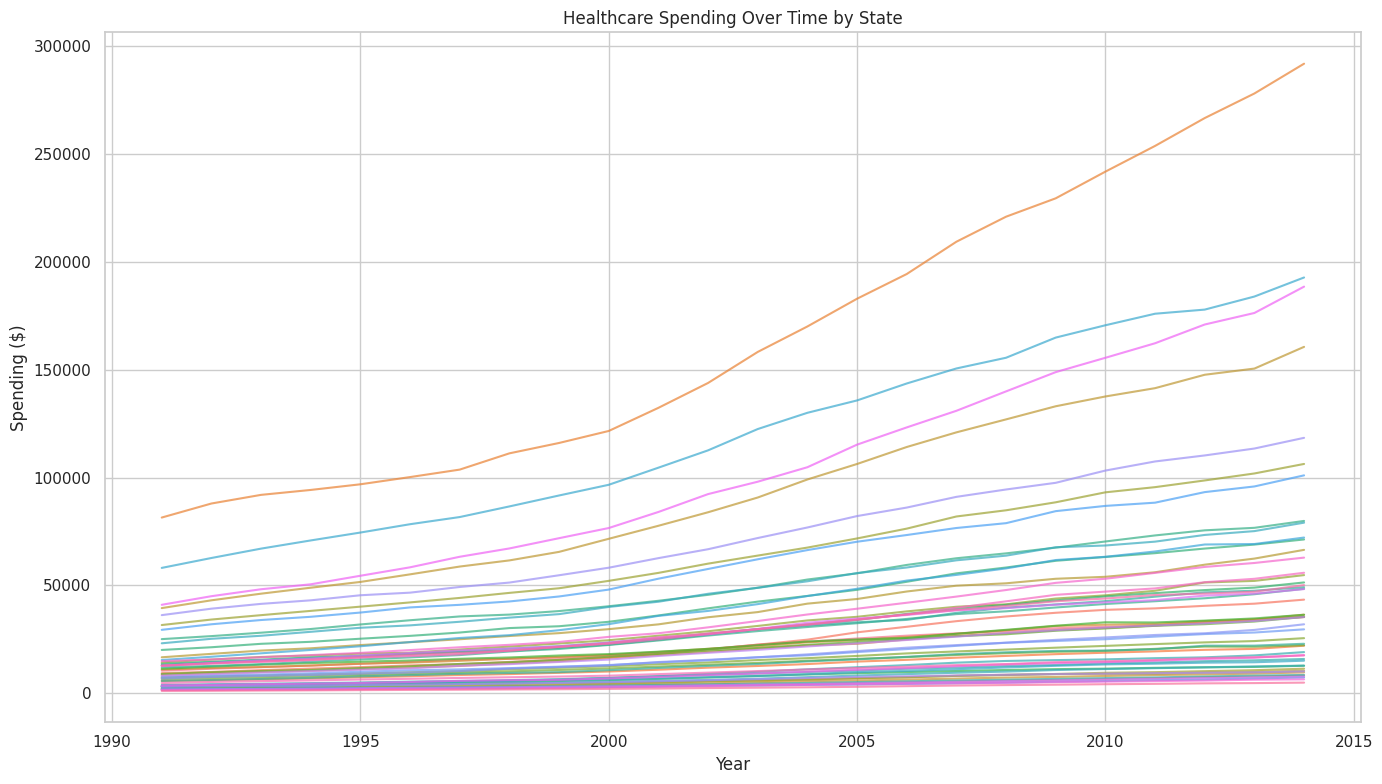

In [63]:
# ==============================================================================
# Cell 9: Healthcare Spending Over Time by State (Fixed)
# ==============================================================================
# Raw URL for Kaiser Family Foundation (KFF) healthcare spending data
healthcare_url = "https://raw.githubusercontent.com/jhu-advdatasci/2018/master/data/KFF/healthcare-spending.csv"

# skiprows=2 ignores the first two header rows containing descriptive file metadata
healthcare_df = pd.read_csv(healthcare_url, skiprows=2)

# Remove empty trailing rows where 'Location' is missing
healthcare_df = healthcare_df.dropna(subset=["Location"])

# Drop non-state national totals and regional aggregates
healthcare_clean = healthcare_df[
    ~healthcare_df["Location"].isin(["United States", "District of Columbia"])
].copy()

# Identify all spending columns by finding headers that start with '19' or '20'
year_cols = [c for c in healthcare_clean.columns if c.startswith("19") or c.startswith("20")]

# Reshape wide table into long format (Location, Year, Spending)
healthcare_long = healthcare_clean.melt(
    id_vars=["Location"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Spending"
)

# Extract only the 4-digit year from strings like "1991__Total Health Spending"
healthcare_long["Year"] = pd.to_numeric(
    healthcare_long["Year"].astype(str).str.extract(r"(\d{4})")[0]
)

# Clean currency strings: remove '$' and ',', then convert to numeric floats
healthcare_long["Spending"] = pd.to_numeric(
    healthcare_long["Spending"].astype(str).str.replace(r"[\$,]", "", regex=True),
    errors="coerce"
)

# Remove any rows where spending values could not be parsed
healthcare_long = healthcare_long.dropna(subset=["Spending"])

# Plot longitudinal spending trajectories color-coded per state
plt.figure(figsize=(14, 8))
sns.lineplot(data=healthcare_long, x="Year", y="Spending", hue="Location", legend=False, alpha=0.7)

# Add plot labels and formatting
plt.title("Healthcare Spending Over Time by State")
plt.xlabel("Year")
plt.ylabel("Spending ($)")
plt.tight_layout()
plt.show()

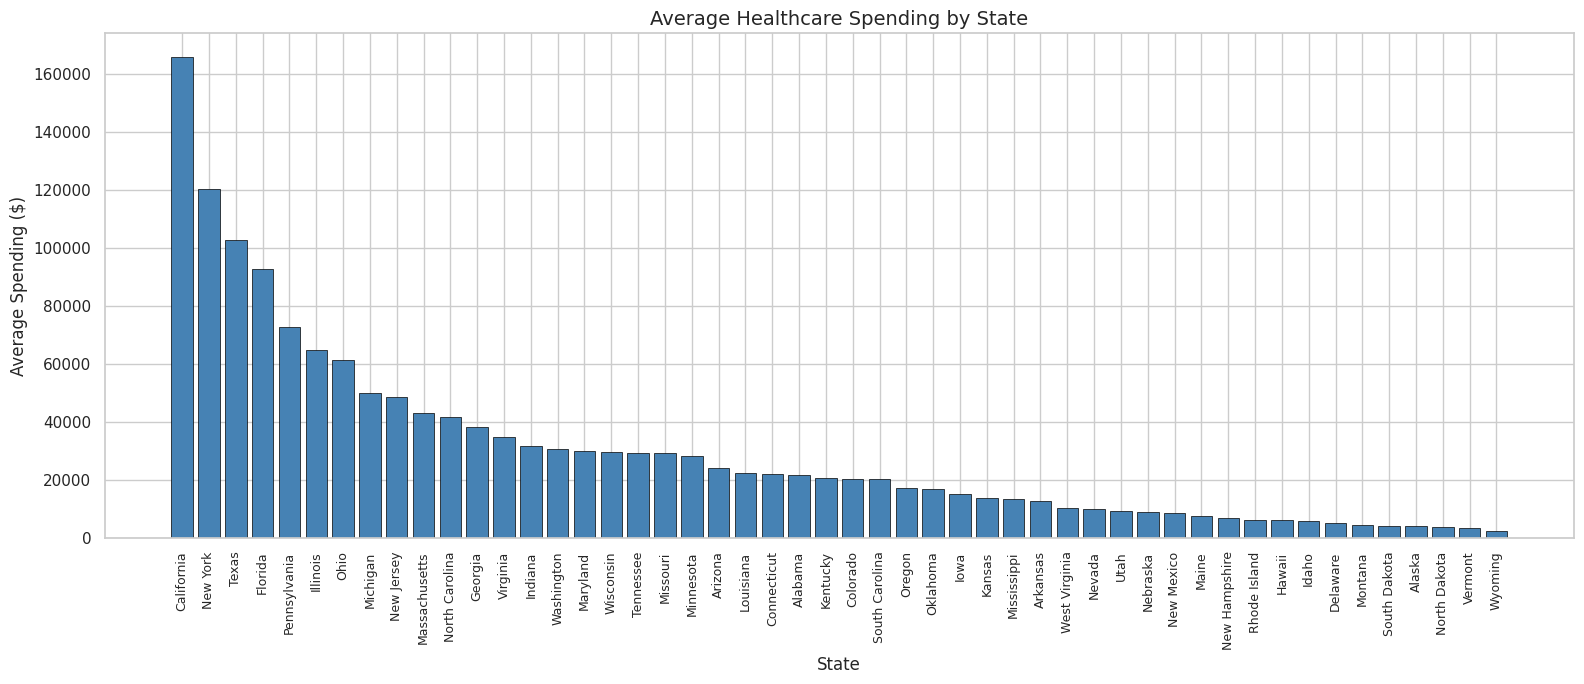

In [64]:
# ==============================================================================
# Cell 10: Matplotlib Barplot of Average Healthcare Spending by State
# ==============================================================================
# Compute mean spending across all recorded years for each state, sorted descending
avg_spending = (
    healthcare_long.groupby("Location")["Spending"]
    .mean()
    .sort_values(ascending=False)
)

# Initialize figure size to fit all states along the x-axis
plt.figure(figsize=(16, 7))

# Create vertical bar plot with matplotlib
plt.bar(avg_spending.index, avg_spending.values, color="steelblue", edgecolor="black", linewidth=0.5)

# Add titles and axis labels
plt.title("Average Healthcare Spending by State", fontsize=14)
plt.xlabel("State", fontsize=12)
plt.ylabel("Average Spending ($)", fontsize=12)

# Rotate state labels vertically (90 degrees) to prevent overlapping
plt.xticks(rotation=90, fontsize=9)

# Adjust layout to fit within the canvas
plt.tight_layout()
plt.show()